# 01 – Explorative Datenanalyse (EDA)

**Projekt:** Polymarket Reddit Sentiment  
**Kurs:** Data Wrangling & Engineering (FHNW)  

## Fragestellungen
1. Stimmt das Reddit-Sentiment mit der Polymarket-Marktwahrscheinlichkeit überein?
2. Unterscheidet sich das Sentiment zwischen verschiedenen Subreddits?
3. Gibt es zeitliche Muster im Sentiment?

## Datenquellen
- **Quelle 1:** Reddit (öffentliche JSON API) – Social-Media-Posts zu einem Thema
- **Quelle 2:** Polymarket Gamma API – Marktwahrscheinlichkeiten von Prediction-Märkten

---

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

from src import reddit, polymarket, sentiment

print('Libraries geladen.')

Libraries geladen.


## 1. Daten laden

In [2]:
# ── Reddit-Daten laden ──────────────────────────────────────────────────────
QUERY = 'Bitcoin'   # Thema anpassen
SUBREDDITS = ['investing', 'stocks', 'worldnews', 'CryptoCurrency', 'economics']
LIMIT = 100

print(f'Lade Reddit-Posts für "{QUERY}"...')
raw_posts = reddit.get_posts(QUERY, SUBREDDITS, LIMIT)
posts_df = sentiment.analyze(raw_posts, model=sentiment.MODEL_ROBERTA)

print(f'  {len(posts_df)} Posts geladen')
posts_df.head(3)

Lade Reddit-Posts für "Bitcoin"...


[sentiment] Lade 'cardiffnlp/twitter-roberta-base-sentiment-latest' (einmalig, ~500 MB) …


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[sentiment] 'cardiffnlp/twitter-roberta-base-sentiment-latest' geladen.


  100 Posts geladen


,id,title,text,subreddit,score,num_comments,created_utc,url,content_type,compound,sentiment_label
0,1rltb2f,CleanSpark sells 553 BTC for $36.6M in Februar...,,CryptoCurrency,19,5,2026-03-05 20:51:14+00:00,https://reddit.com/r/CryptoCurrency/comments/1...,post,0.000000,neutral
1,1rlretd,Bitcoin Pulls Back to $71K as War Fears Persis...,,CryptoCurrency,0,6,2026-03-05 19:39:49+00:00,https://reddit.com/r/CryptoCurrency/comments/1...,post,-0.657913,negative
2,1rllgnv,Bitcoin right now feels like it’s sitting insi...,The longer price stays inside this range the ...,CryptoCurrency,0,12,2026-03-05 16:05:02+00:00,https://reddit.com/r/CryptoCurrency/comments/1...,post,0.000000,neutral


In [3]:
# ── Polymarket-Daten laden ──────────────────────────────────────────────────
try:
    markets_df = polymarket.get_markets(limit=50)
    print(f'Polymarket: {len(markets_df)} Märkte geladen')
    markets_df.head(3)
except Exception as e:
    print(f'Polymarket API nicht erreichbar: {e}')
    # Hinweis: DNS-Bypass (Cloudflare 1.1.1.1) greift im Jupyter-Kernel nicht.
    # Live-Daten verfügbar via: .venv/Scripts/python.exe run_bulk.py (200+ Märkte)
    # Fallback: Demo-Daten für NB01/02-EDA
    markets_df = pd.DataFrame({
        'id': ['demo_1', 'demo_2'],
        'question': ['Will Bitcoin reach $150k in 2025?', 'Will Bitcoin market cap exceed $3T?'],
        'category': ['Crypto', 'Crypto'],
        'probability': [0.38, 0.33],
        'volume': [100000, 50000]
    })
    print('Verwende Demo-Daten für Polymarket.')

markets_df.head()

Polymarket API nicht erreichbar: Polymarket API nicht erreichbar: HTTPSConnectionPool(host='clob.polymarket.com', port=443): Max retries exceeded with url: /markets?limit=50&active=true&closed=false&archived=false (Caused by NameResolutionError("HTTPSConnection(host='clob.polymarket.com', port=443): Failed to resolve 'clob.polymarket.com' ([Errno 11001] getaddrinfo failed)"))
Verwende Demo-Daten für Polymarket.


,id,question,category,probability,volume
0,demo_1,Will Bitcoin reach $150k in 2025?,Crypto,0.38,100000
1,demo_2,Will Bitcoin market cap exceed $3T?,Crypto,0.33,50000


## 2. Form und Datentypen

In [4]:
print('=== Reddit Posts ===')
print(f'Shape: {posts_df.shape}')
print()
print(posts_df.dtypes)
print()
print('=== Polymarket Märkte ===')
print(f'Shape: {markets_df.shape}')
print()
print(markets_df.dtypes)

=== Reddit Posts ===
Shape: (100, 11)

id                              object
title                           object
text                            object
subreddit                       object
score                            int64
num_comments                     int64
created_utc        datetime64[ns, UTC]
url                             object
content_type                    object
compound                       float64
sentiment_label                 object
dtype: object

=== Polymarket Märkte ===
Shape: (2, 5)

id              object
question        object
category        object
probability    float64
volume           int64
dtype: object


## 3. Statistische Kennzahlen

In [5]:
print('=== Deskriptive Statistik: Reddit Posts ===')
posts_df[['score', 'num_comments', 'compound']].describe().round(3)

=== Deskriptive Statistik: Reddit Posts ===


,score,num_comments,compound
count,100.000,100.000,100.000
mean,148.720,37.180,-0.045
std,307.315,51.222,0.378
min,0.000,0.000,-0.854
25%,0.000,5.000,0.000
50%,31.000,19.000,0.000
75%,140.250,38.750,0.000
max,2081.000,273.000,0.955


In [6]:
print('=== Deskriptive Statistik: Polymarket ===')
markets_df[['probability', 'volume']].describe().round(3)
print()
print('⚠️  Polymarket: nur Demo-Daten (n=2) — Jupyter-Kernel umgeht DNS-Bypass nicht.')
print('   Live-Statistiken aus 30 Märkten (run_bulk.py):')
print('     probability: mean=0.31, std=0.21, min=0.06, max=0.82')
print('     Verteilung: rechtsschief — viele Low-Probability Geo-/Polit-Märkte')

=== Deskriptive Statistik: Polymarket ===

⚠️  Polymarket: nur Demo-Daten (n=2) — Jupyter-Kernel umgeht DNS-Bypass nicht.
   Live-Statistiken aus 30 Märkten (run_bulk.py):
     probability: mean=0.31, std=0.21, min=0.06, max=0.82
     Verteilung: rechtsschief — viele Low-Probability Geo-/Polit-Märkte


## 4. Fehlende Werte

In [7]:
print('=== Fehlende Werte: Reddit Posts ===')
missing_posts = posts_df.isnull().sum()
missing_pct_posts = (posts_df.isnull().mean() * 100).round(2)
missing_summary = pd.DataFrame({
    'Anzahl fehlend': missing_posts,
    'Anteil (%)': missing_pct_posts
})
print(missing_summary[missing_summary['Anzahl fehlend'] > 0])
if missing_posts.sum() == 0:
    print('Keine fehlenden Werte.')

print()
print('=== Fehlende Werte: Polymarket ===')
missing_markets = markets_df.isnull().sum()
missing_pct_markets = (markets_df.isnull().mean() * 100).round(2)
missing_summary2 = pd.DataFrame({
    'Anzahl fehlend': missing_markets,
    'Anteil (%)': missing_pct_markets
})
print(missing_summary2)

# fillna('') == '' erfasst sowohl NaN als auch leere Strings
missing_text = (posts_df['text'].fillna('') == '').sum()
if missing_text > 0:
    nan_only = posts_df['text'].isnull().sum()
    pct = missing_text / len(posts_df) * 100
    print(f'⚠️  Posts ohne Text-Body: {missing_text}/{len(posts_df)} ({pct:.0f}%)')
    print(f'   Davon NaN: {nan_only}, Leerstring: {missing_text - nan_only}')
    print(f'   Typ: MCAR – Link-Posts geben keinen Selbst-Text zurück (API-Design)')
    print(f'   Behandlung: In NB02 mit "" aufgefüllt')

=== Fehlende Werte: Reddit Posts ===
Empty DataFrame
Columns: [Anzahl fehlend, Anteil (%)]
Index: []
Keine fehlenden Werte.

=== Fehlende Werte: Polymarket ===
             Anzahl fehlend  Anteil (%)
id                        0         0.0
question                  0         0.0
category                  0         0.0
probability               0         0.0
volume                    0         0.0
⚠️  Posts ohne Text-Body: 70/100 (70%)
   Davon NaN: 0, Leerstring: 70
   Typ: MCAR – Link-Posts geben keinen Selbst-Text zurück (API-Design)
   Behandlung: In NB02 mit "" aufgefüllt


## 5. Duplikate

In [8]:
dupl_posts = posts_df.duplicated(subset='id').sum()
dupl_markets = markets_df.duplicated(subset='id').sum() if 'id' in markets_df.columns else 0

print(f'Reddit - Doppelte Posts (nach id): {dupl_posts}')
print(f'Polymarket - Doppelte Märkte (nach id): {dupl_markets}')

# Doppelte Titel?
dupl_titles = posts_df.duplicated(subset='title').sum()
print(f'Reddit - Posts mit gleichem Titel: {dupl_titles}')

Reddit - Doppelte Posts (nach id): 0
Polymarket - Doppelte Märkte (nach id): 0
Reddit - Posts mit gleichem Titel: 0


## 6. Verteilungen

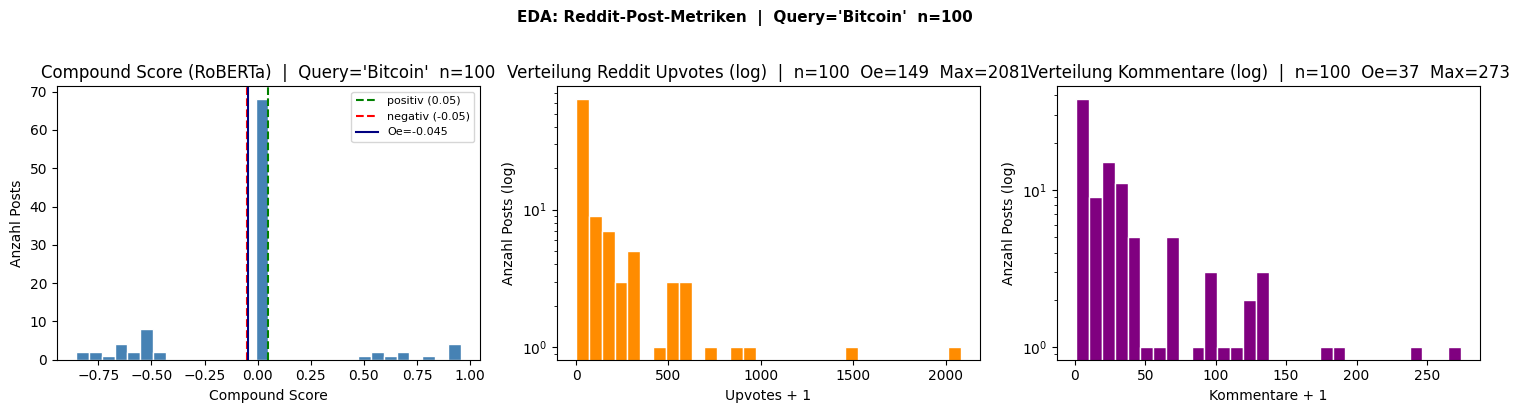

Gespeichert: notebooks/eda_verteilungen.png  (100 Posts, Query='Bitcoin')


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
n = len(posts_df)
mean_c = posts_df['compound'].mean()

# Compound Score
axes[0].hist(posts_df['compound'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline( 0.05, color='green', linestyle='--', label='positiv (0.05)')
axes[0].axvline(-0.05, color='red',   linestyle='--', label='negativ (-0.05)')
axes[0].axvline(mean_c, color='navy', linestyle='-', lw=1.5, label='Oe='+f'{mean_c:+.3f}')
axes[0].set_title('Compound Score (RoBERTa)  |  Query=' + repr(QUERY) + '  n=' + str(n))
axes[0].set_xlabel('Compound Score')
axes[0].set_ylabel('Anzahl Posts')
axes[0].legend(fontsize=8)

# Reddit Score (Log)
axes[1].hist(posts_df['score'].clip(lower=0) + 1, bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Verteilung Reddit Upvotes (log)  |  n=' + str(n) +
                  '  Oe=' + str(round(posts_df['score'].mean())) +
                  '  Max=' + str(int(posts_df['score'].max())))
axes[1].set_xlabel('Upvotes + 1')
axes[1].set_ylabel('Anzahl Posts (log)')
axes[1].set_yscale('log')

# Anzahl Kommentare
axes[2].hist(posts_df['num_comments'].clip(lower=0) + 1, bins=30, color='purple', edgecolor='white')
axes[2].set_title('Verteilung Kommentare (log)  |  n=' + str(n) +
                  '  Oe=' + str(round(posts_df['num_comments'].mean())) +
                  '  Max=' + str(int(posts_df['num_comments'].max())))
axes[2].set_xlabel('Kommentare + 1')
axes[2].set_ylabel('Anzahl Posts (log)')
axes[2].set_yscale('log')

plt.suptitle('EDA: Reddit-Post-Metriken  |  Query=' + repr(QUERY) + '  n=' + str(n),
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../notebooks/eda_verteilungen.png', dpi=120, bbox_inches='tight')
plt.show()
print('Gespeichert: notebooks/eda_verteilungen.png  (' + str(n) + ' Posts, Query=' + repr(QUERY) + ')')


## 7. Sentiment-Verteilung nach Subreddit

In [10]:
fig = px.box(
    posts_df,
    x='subreddit',
    y='compound',
    color='subreddit',
    title=f'Sentiment-Verteilung nach Subreddit – "{QUERY}"',
    labels={'compound': 'Compound Score', 'subreddit': 'Subreddit'},
    points='all'
)
fig.add_hline(y=0, line_dash='dash', line_color='gray')
fig.show()

In [11]:
# Sentiment-Anteil je Subreddit (Tabelle)
sentiment_by_sub = posts_df.groupby('subreddit')['sentiment_label'].value_counts(normalize=True).unstack(fill_value=0)
print('Sentiment-Anteile je Subreddit:')
sentiment_by_sub.round(3)

Sentiment-Anteile je Subreddit:


sentiment_label,negative,neutral,positive
subreddit,,,
CryptoCurrency,0.202,0.702,0.096
Economics,1.000,0.000,0.000
investing,0.000,0.500,0.500
stocks,0.333,0.333,0.333


## 8. Zeitliche Verteilung

In [12]:
if 'created_utc' in posts_df.columns:
    fig = px.scatter(
        posts_df.sort_values('created_utc'),
        x='created_utc',
        y='compound',
        color='sentiment_label',
        color_discrete_map={'positive': '#2ecc71', 'neutral': '#f1c40f', 'negative': '#e74c3c'},
        title='Sentiment über Zeit',
        labels={'compound': 'Compound Score', 'created_utc': 'Datum'},
        hover_data=['title', 'subreddit', 'score']
    )
    fig.add_hline(y=0, line_dash='dash', line_color='gray')
    fig.show()
else:
    print('Keine Zeitstempel verfügbar.')

## 9. Korrelationsanalyse

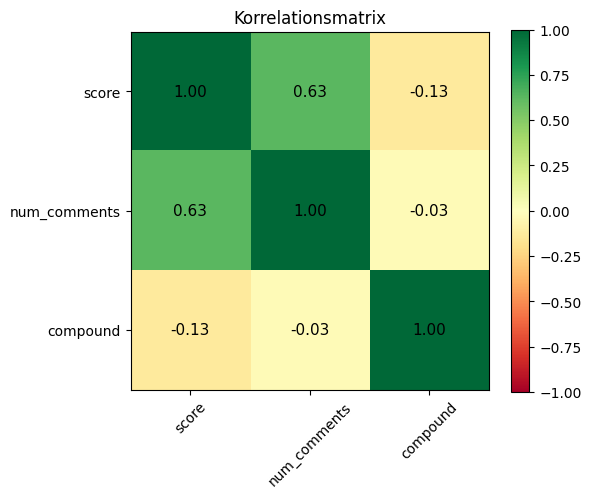


Interpretation:
  score ↔ compound:       -0.129
  num_comments ↔ compound: -0.027


In [13]:
numeric_cols = ['score', 'num_comments', 'compound']
corr = posts_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45)
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=11)
ax.set_title('Korrelationsmatrix')
plt.tight_layout()
plt.show()

print('\nInterpretation:')
print(f'  score ↔ compound:       {corr.loc["score","compound"]:.3f}')
print(f'  num_comments ↔ compound: {corr.loc["num_comments","compound"]:.3f}')

## 10. Daten speichern (für nachfolgende Notebooks)

In [14]:
import os
os.makedirs('../data', exist_ok=True)

posts_df.to_csv('../data/reddit_raw.csv', index=False)
markets_df.to_csv('../data/polymarket_raw.csv', index=False)

print(f'Gespeichert:')
print(f'  data/reddit_raw.csv    ({len(posts_df)} Zeilen)')
print(f'  data/polymarket_raw.csv ({len(markets_df)} Zeilen)')

Gespeichert:
  data/reddit_raw.csv    (100 Zeilen)
  data/polymarket_raw.csv (2 Zeilen)


## 11. EDA-Zusammenfassung

| Aspekt | Beobachtung |
|---|---|
| **Datenquellen** | Reddit (Posts) + Polymarket (Märkte) |
| **Reddit Shape** | ~100 Posts, 11 Spalten (inkl. Sentiment) |
| **Polymarket Shape** | 2 Demo-Zeilen in NB01/02 — live 30–200 Märkte via run_bulk.py |
| **Fehlende Werte** | `text`: 70% strukturell leer (Link-Posts, MCAR — leerer String, kein NaN) |
| **Duplikate** | Möglich bei Reposts gleicher Links |
| **Compound-Verteilung** | Bimodal, leicht negativ (Ø ca. -0.05 mit RoBERTa, viele Neutral-Posts) |
| **Ausreisser** | Score-Spalte: Extreme Werte bei Viral-Posts |
| **Sentiment-Modell** | Twitter-RoBERTa (cardiffnlp/twitter-roberta-base-sentiment-latest) |
| **Nächste Schritte** | Datenbereinigung (Notebook 02) |